In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'C:\Users\Marcus\Desktop\python pandas\superstore_data\version_control\superstore_clean.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,31518,CA-2012-169397,2012-12-24,2013-01-09,First Class,JB-15925,Joni Blumstein,Consumer,Dublin,Ohio,...,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,19.7760,4,0.70,-13.84,0.79,Medium
1,6224,US-2011-144729,2011-07-21,2011-08-07,First Class,SS-20140,Saphhira Shifley,Corporate,San Miguelito,Panama,...,OFF-FA-10002247,Office Supplies,Fasteners,"Oic Paper Clips, Bulk Pack",11.5440,2,0.40,-5.22,0.97,Medium
2,15333,IT-2014-4749412,2014-09-18,2014-09-28,Standard Class,MB-18085,Mick Brown,Unknown,Birmingham,England,...,OFF-AR-10003113,Office Supplies,Art,"Binney & Smith Pens, Blue",29.8500,5,0.50,-4.80,3.71,Medium
3,49259,NI-2013-4420,2013-04-10,2013-10-26,Standard Class,MP-7965,Michael Paige,Corporate,Lagos,Lagos,...,OFF-AVE-10004512,Office Supplies,Binders,"Avery Hole Reinforcements, Economy",1.3230,1,0.70,-3.09,0.06,Medium
4,24199,IN-2014-14423,2014-10-29,2014-11-27,First Class,DL-12925,Daniel Lacy,Consumer,Kendari,Sulawesi Tenggara,...,FUR-FU-10002362,Furnitures,Furnishings,"Advantus Door Stop, Black",131.4876,4,0.27,25.17,0.00,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51365,17526,ES-2014-2057259,2014-08-02,2014-05-19,First Class,PB-19150,Philip Brown,Consumer,Cagnes-Sur-Mer,Provence-Alpes-Cote D'Azur,...,OFF-PA-10002616,Office Supplies,Paper,"Green Bar Parchment Paper, Multicolor",108.5400,6,0.00,34.56,11.76,Medium
51366,36055,CA-2011-121573,2011-11-03,2011-08-07,Standard Class,SG-20605,Speros Goranitis,Consumer,New York City,New York,...,TEC-PH-10000984,Technology,Phones,Panasonic Kx-Tg9471B,783.9600,4,0.00,219.51,64.42,High
51367,43576,TU-2011-9190,2011-12-23,2012-01-11,Second Class,CM-1830,Cari Macintyre,Corporate,Corum,Corum,...,OFF-KIT-10002357,Office Supplies,Appliances,"Kitchenaid Blender, White",39.8400,1,0.60,-12.96,5.84,Medium
51368,22403,IN-2013-35388,2013-08-07,2013-11-19,Standard Class,IM-15055,Unknown,Consumer,Jakarta,Jakarta,...,OFF-AR-10000058,Office Supplies,Art,"Stanley Canvas, Water Color",38.4345,1,0.27,3.66,2.96,Medium


In [4]:
# What are the top 10 most unprofitable specific products (bleeding money)?

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51370 entries, 0 to 51369
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51370 non-null  int64  
 1   Order ID        51370 non-null  str    
 2   Order Date      51370 non-null  str    
 3   Ship Date       51370 non-null  str    
 4   Ship Mode       51370 non-null  str    
 5   Customer ID     51370 non-null  str    
 6   Customer Name   51336 non-null  str    
 7   Segment         51370 non-null  str    
 8   City            51351 non-null  str    
 9   State           51339 non-null  str    
 10  Country         51370 non-null  str    
 11  Postal Code     51370 non-null  int64  
 12  Market          51370 non-null  str    
 13  Region          51370 non-null  str    
 14  Product ID      51370 non-null  str    
 15  Category        51370 non-null  str    
 16  Sub-Category    51370 non-null  str    
 17  Product Name    51370 non-null  str    
 1

In [6]:
unprofitable_products = df.groupby(df['Product ID'])[['Sales','Profit']].agg(
    total_sales = ('Sales','sum'),
    total_profit = ('Profit','sum')
).round(2).sort_values(['total_profit','total_sales'], ascending=False)
unprofitable_products

,total_sales,total_profit
Product ID,,
TEC-CO-10004722,61599.82,25199.94
OFF-AP-10004512,21147.08,10345.58
TEC-PH-10004823,22262.10,8121.47
OFF-BI-10003527,27453.38,7753.04
TEC-CO-10001449,18839.69,6983.89
...,...,...
TEC-MOT-10003050,10348.76,-3998.69
TEC-PH-10002991,7259.16,-4574.65
TEC-MA-10000822,16829.90,-4589.97


In [7]:
# showing negative profits only
unprofitable_products[(unprofitable_products['total_sales'] < 0) | (unprofitable_products['total_profit'] < 0)]

,total_sales,total_profit
Product ID,,
FUR-CH-10004289,2389.90,-0.01
OFF-AP-10004499,322.97,-0.01
OFF-BI-10002931,314.55,-0.01
OFF-EN-10003628,306.77,-0.03
OFF-SU-10004784,49.28,-0.04
...,...,...
TEC-MOT-10003050,10348.76,-3998.69
TEC-PH-10002991,7259.16,-4574.65
TEC-MA-10000822,16829.90,-4589.97


In [13]:
product = df[['Product ID','Product Name']]
product.set_index('Product ID', inplace=True)
product

,Product Name
Product ID,
OFF-BI-10002852,Ibico Standard Transparent Covers
OFF-FA-10002247,"Oic Paper Clips, Bulk Pack"
OFF-AR-10003113,"Binney & Smith Pens, Blue"
OFF-AVE-10004512,"Avery Hole Reinforcements, Economy"
FUR-FU-10002362,"Advantus Door Stop, Black"
...,...
OFF-PA-10002616,"Green Bar Parchment Paper, Multicolor"
TEC-PH-10000984,Panasonic Kx-Tg9471B
OFF-KIT-10002357,"Kitchenaid Blender, White"


In [17]:
products_profitability = pd.merge(unprofitable_products, product, left_index=True, right_index=True, how="inner")

In [18]:
products_profitability

,total_sales,total_profit,Product Name
Product ID,,,
TEC-CO-10004722,61599.82,25199.94,Canon Imageclass 2200 Advanced Copier
TEC-CO-10004722,61599.82,25199.94,Canon Imageclass 2200 Advanced Copier
TEC-CO-10004722,61599.82,25199.94,Canon Imageclass 2200 Advanced Copier
TEC-CO-10004722,61599.82,25199.94,Canon Imageclass 2200 Advanced Copier
TEC-CO-10004722,61599.82,25199.94,Canon Imageclass 2200 Advanced Copier
...,...,...,...
OFF-AP-10001623,11728.83,-4958.16,"Hoover Stove, White"
OFF-AP-10001623,11728.83,-4958.16,"Hoover Stove, White"
TEC-MA-10000418,11099.96,-8879.97,Cubify Cubex 3D Printer Double Head Print


In [24]:
topten_unprofitable_prod = products_profitability[products_profitability['total_profit'] < 0].sort_values(by='total_profit').drop_duplicates().head(10)
topten_unprofitable_prod

,total_sales,total_profit,Product Name
Product ID,,,
TEC-MA-10000418,11099.96,-8879.97,Cubify Cubex 3D Printer Double Head Print
OFF-AP-10001623,11728.83,-4958.16,"Hoover Stove, White"
TEC-MA-10000822,16829.90,-4589.97,Lexmark Mx611Dhe Monochrome Laser Printer
TEC-PH-10002991,7259.16,-4574.65,"Apple Smart Phone, Full Size"
TEC-MOT-10003050,10348.76,-3998.69,"Motorola Smart Phone, Cordless"
TEC-MA-10004125,7999.98,-3839.99,Cubify Cubex 3D Printer Triple Head Print
FUR-CH-10001582,6497.28,-3066.77,"Office Star Executive Leather Armchair, Black"
FUR-TA-10000198,9917.64,-2876.11,Chromcraft Bull-Nose Wood Oval Conference Tabl...
FUR-TA-10002885,1199.35,-2798.49,"Lesro Computer Table, Fully Assembled"


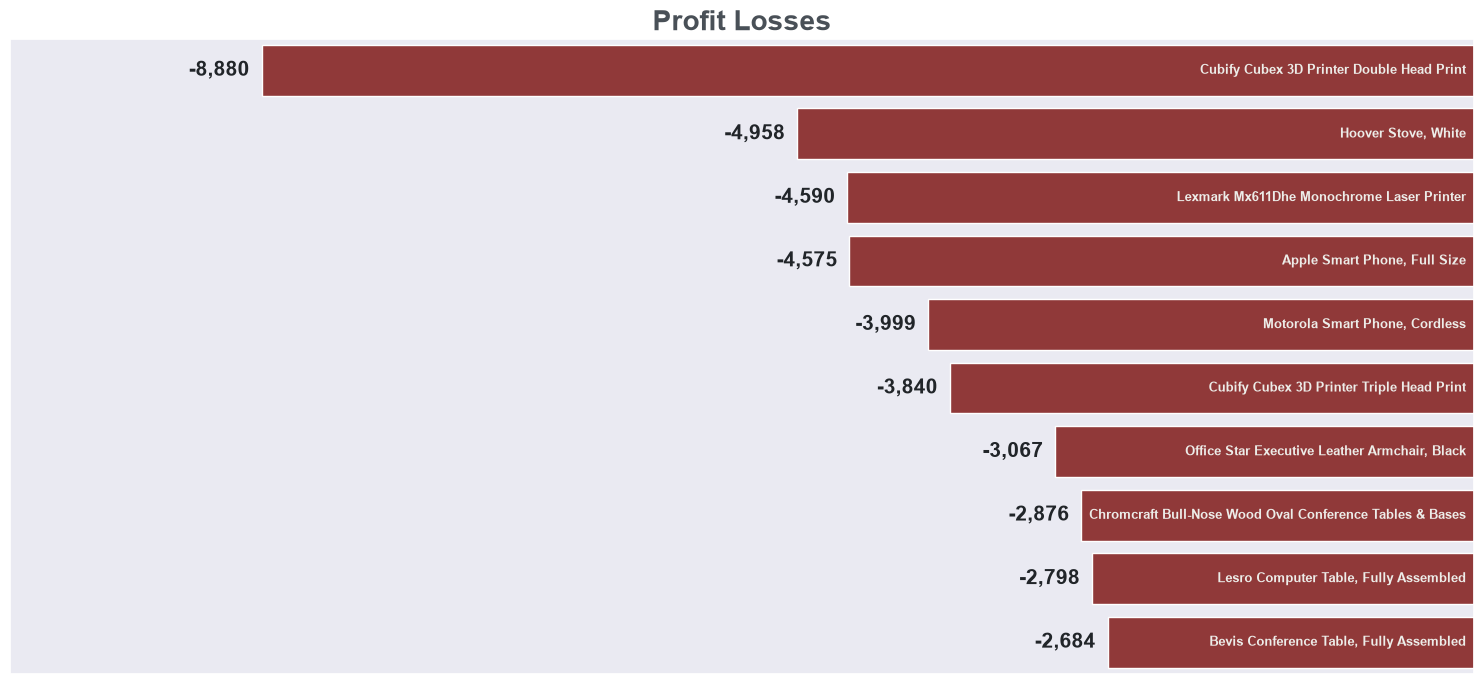

In [65]:
sns.set_theme()

fig, ax = plt.subplots(figsize=(15,7))

sns.barplot(
    data=topten_unprofitable_prod,
    x='total_profit',
    y='Product Name',
    ax=ax,
    color='#9e2a2b'
)
ax.grid(False)
ax.set_title('Profit Losses', fontsize=20, fontweight='bold', color='#495057')

# ==================== remove default y-axis ====================
ax.set_ylabel('')
ax.set_yticklabels([])
ax.tick_params(left=False)          # hide the tick marks too

# ==================== x-axis ====================
ax.set_xlabel('')
ax.set_xticklabels([])
ax.tick_params(bottom=False)   

# ==================== product name labels (in place of y-axis, right-aligned at x=0) ====================
for i, name in enumerate(topten_unprofitable_prod['Product Name']):
    ax.text(
        0, i, name + '  ',      # small padding via trailing spaces
        ha='right', va='center',
        fontweight='bold', fontsize=9,
        color='#edede9'
    )

# ==================== value labels beside bar, left side (tip of bar) ====================
for i, val in enumerate(topten_unprofitable_prod['total_profit']):
    ax.text(
        val, i, f'{val:,.0f}  ',
        ha='right', va='center',
        fontweight='bold', fontsize=15,
        color='#212529'
    )

# give the labels room so they don't get clipped
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin * 1.15, xmax)

plt.tight_layout()
plt.show()

In [66]:
# Business Question 6:
# What are the top 10 most unprofitable specific products (bleeding money)

# Answer:
# The product that receives a massive hit of decline belongs to Printer category, Cubify Cubex with a total profit losses of $9k whilst the least
# amount of decrease goes to Bevis Conferenc in Table category.